# Distribution Analysis


Distribution analysis evaluates how feature values are spread across a population, identifying central trends, asymmetry, and heavy tails within the dataset

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 1. Normal Distribution
A continuous probability distribution that is symmetric around its mean ($\mu$), following a bell-shaped curve defined by equation 

$f(x) = \frac{1}{\sigma\sqrt{2\pi}} e^{-\frac{1}{2}\left(\frac{x-\mu}{\sigma}\right)^2}$.

Churn Dataset Analysis:

* Shape: Standard parametric models assume customer behavioral metrics follow Gaussian curves, though continuous features in churn data often deviate into rectangular or skewed shapes.

* Center: Age has a Mean of 43.58 and Median of 43.00, aligning near the center.

* Spread: Standard deviation ($\sigma$) is 14.92 with an Interquartile Range (IQR) of 25.00 across the range [18.00, 69.00].

* Skewness: $-0.0120$ (close to 0).

* Outliers: Zero extreme outliers, though kurtosis indicates flat tails rather than classic bell-curve Gaussian tapering.

#### AI/ML Usage

Algorithms like Gaussian Naive Bayes, Linear Discriminant Analysis (LDA), and z-score feature scalers explicitly assume normally distributed input variables.

In [2]:
import pandas as pd
import numpy as np
import scipy.stats as stats

df = pd.read_csv('customer_churn.csv')

# Testing Normality on Age column using Shapiro-Wilk test

stat, p_value = stats.shapiro(df['Age'].dropna())
print(f"Age Mean: {df['Age'].mean():.2f}, Median: {df['Age'].median():.2f}")
print(f"Shapiro-Wilk Statistic: {stat:.4f}, p-value: {p_value:.4e}")

Age Mean: 43.58, Median: 43.00
Shapiro-Wilk Statistic: 0.9557, p-value: 2.1685e-36


### 2. Uniform Distribution
A distribution where all outcome intervals of equal length within bounds $[a, b]$ have an identical constant probability density

$f(x) = \frac{1}{b - a}$.

Churn Dataset Analysis:

* Shape: Rectangular and flat across the entire range.

* Center: TenureYears has a Mean of 5.04 years and Median of 5.00 years.

* Spread: Standard deviation of 3.16 years and IQR of 6.00 years over the discrete integer domain $[0, 10]$.

* Skewness: $-0.0257$ (nearly zero).

* Outliers: No outliers; data points are spread evenly from new sign-ups (0 years) to long-term accounts (10 years).

#### AI/ML Usage

Hyperparameter tuning spaces (e.g., Random Search bounds) and baseline mock data generators frequently draw from uniform distributions.

In [3]:
tenure_counts = df['TenureYears'].value_counts().sort_index()
print("Tenure Years Frequency Distribution:\n", tenure_counts)
print(f"Tenure Std: {df['TenureYears'].std():.2f}, IQR: {df['TenureYears'].quantile(0.75) - df['TenureYears'].quantile(0.25):.2f}")

Tenure Years Frequency Distribution:
 TenureYears
0     449
1     467
2     435
3     435
4     425
5     486
6     502
7     438
8     430
9     502
10    451
Name: count, dtype: int64
Tenure Std: 3.16, IQR: 6.00


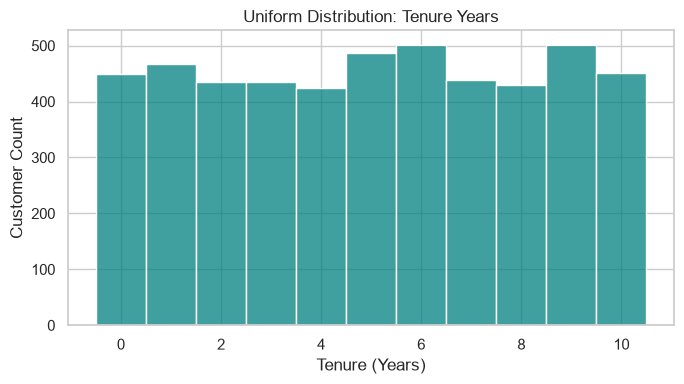

In [17]:
plt.figure(figsize=(7, 4))
sns.histplot(df['TenureYears'], discrete=True, color='teal')

plt.title('Uniform Distribution: Tenure Years')
plt.xlabel('Tenure (Years)')
plt.ylabel('Customer Count')
plt.tight_layout()
plt.show()

### 3. Skewness
A measure of asymmetry in a probability distribution relative to its mean, calculated as

$S = \frac{E[(X - \mu)^3]}{\sigma^3}$. 

$S = 0$ indicates perfect symmetry, $S > 0$ indicates right skew, and $S < 0$ indicates left skew.

Churn Dataset Analysis:

* Shape: Asymmetric tail pull. TotalCharges shows pronounced rightward stretching ($S = 0.8001$).
  
* Center: Mean ($4,679.13) is shifted significantly above Median ($3,830.98).

* Spread: Standard deviation ($3,468.39) and IQR ($5,033.98) reflect substantial dispersion.

* Skewness: $0.8001$ (moderately positive).

* Outliers: 23 high-value upper outliers detected via $1.5 \times IQR$ exceeding $14,468.09.

#### AI/ML Usage

Skewed features distort linear regression estimates; apply log or Power Transformers ($\log(x+1)$) to stabilize variance.

In [4]:
skewness_table = df[['Age', 'TenureYears', 'MonthlyCharges', 'TotalCharges', 'SupportCalls']].skew()
print("Feature Skewness Metrics:\n", skewness_table)

Feature Skewness Metrics:
 Age              -0.012003
TenureYears      -0.025737
MonthlyCharges   -0.023257
TotalCharges      0.800107
SupportCalls      0.686315
dtype: float64


### 4. Kurtosis
A measure of the "tailedness" and peak height of a distribution relative to a normal curve, calculated as

$K = \frac{E[(X - \mu)^4]}{\sigma^4} - 3$. 

Excess kurtosis $> 0$ (leptokurtic) indicates heavy tails/outliers

$< 0$ (platykurtic) indicates flat tails.

Churn Dataset Analysis:

* Shape: MonthlyCharges exhibits a platykurtic, flattened profile (Kurtosis $= -1.1892$).
  
* Center: Mean ($70.09) and Median ($70.16) sit at the center.

* Spread: Standard deviation of $28.85 and IQR of $49.04 over continuous values $[20.02, 119.98]$.

* Skewness: $-0.0233$ (symmetric flat plateau).

* Outliers: 0 extreme outliers due to constrained minimum and maximum plan pricing bounds.

#### AI/ML Usage

High kurtosis warns machine learning pipelines about extreme outlier risk requiring robust estimators (e.g., Huber Loss, RobustScaler).

In [5]:
kurtosis_table = df[['Age', 'TenureYears', 'MonthlyCharges', 'TotalCharges', 'SupportCalls']].kurtosis()
print("Excess Kurtosis Metrics:\n", kurtosis_table)

Excess Kurtosis Metrics:
 Age              -1.177785
TenureYears      -1.215717
MonthlyCharges   -1.189176
TotalCharges     -0.143017
SupportCalls      0.348473
dtype: float64


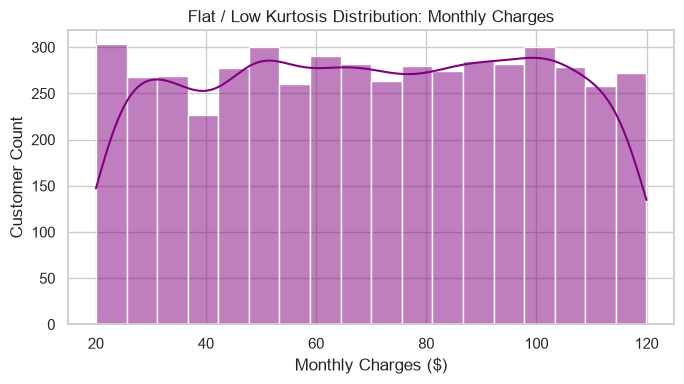

In [18]:
plt.figure(figsize=(7, 4))
sns.histplot(df['MonthlyCharges'], kde=True, color='purple')

plt.title('Flat / Low Kurtosis Distribution: Monthly Charges')
plt.xlabel('Monthly Charges ($)')
plt.ylabel('Customer Count')
plt.tight_layout()
plt.show()

### 5. Symmetric Distribution
A distribution where the left and right halves are mirror images around the center point, causing $\text{Mean} \approx \text{Median} \approx \text{Mode}$.

Churn Dataset Analysis:

* Shape: Uniformly spread and balanced on both sides of the midpoint. Age serves as an example.

* Center: Mean is 43.58 and Median is 43.00.

* Spread: Standard deviation is 14.92; IQR is 25.00 spanning from 18 to 69 years old.

* Skewness: $-0.0120$ (virtually unskewed).

* Outliers: 0 outliers present.

#### AI/ML Usage

Symmetric features simplify standard preprocessing steps like min-max scaling and linear correlation analysis.

In [6]:
df['Age'].mean()

np.float64(43.58059971825317)

In [8]:
df['Age'].median()

np.float64(43.0)

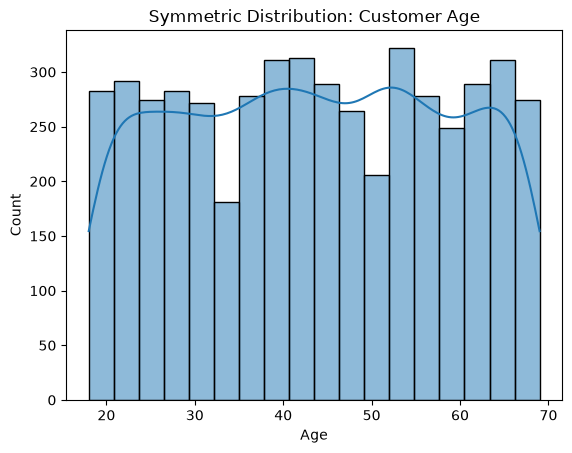

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df['Age'], kde=True)
plt.title('Symmetric Distribution: Customer Age')
plt.show()

### 6. Left-Skewed Distribution (Negative Skew)

A distribution with an elongated tail extending toward lower values on the left side, where $\text{Mean} < \text{Median}$.

Churn Dataset Analysis:

* Shape: Long lower tail created by applying a log transformation to TotalCharges ($\log(1 + \text{TotalCharges})$).

* Center: Mean is 8.07, pulled below the Median of 8.25.

* Spread: Standard deviation is 1.03; IQR is 1.30 across the range $[3.41, 9.65]$.

* Skewness: $-1.0968$ (strongly left-skewed).

* Outliers: 151 lower-tail outliers caused by low initial total charges from new accounts.

#### AI/ML Usage

Left-skewed target variables can lead models to overpredict low values; power transformations help restore symmetry.

In [11]:
# Log-transform TotalCharges to demonstrate left-skewed profile

df['Log_TotalCharges'] = np.log1p(df['TotalCharges'])

mean_log = df['Log_TotalCharges'].mean()
median_log = df['Log_TotalCharges'].median()
skew_log = df['Log_TotalCharges'].skew()

print(f"Log TotalCharges -> Mean: {mean_log:.2f}, Median: {median_log:.2f}, Skewness: {skew_log:.4f}")

Log TotalCharges -> Mean: 8.07, Median: 8.25, Skewness: -1.0968


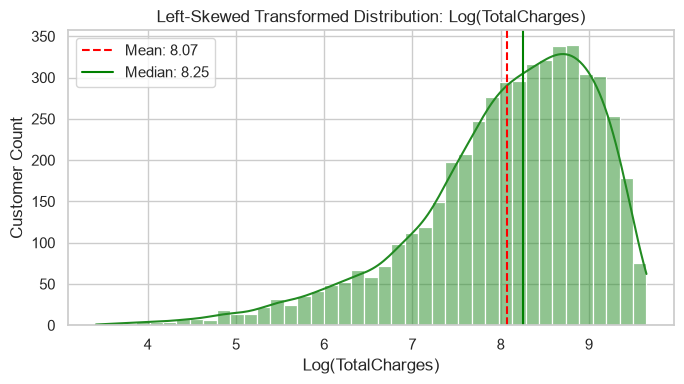

In [19]:
df['Log_TotalCharges'] = np.log1p(df['TotalCharges'])

plt.figure(figsize=(7, 4))
sns.histplot(df['Log_TotalCharges'], kde=True, color='forestgreen')

plt.axvline(df['Log_TotalCharges'].mean(), color='red', linestyle='--', label=f"Mean: {df['Log_TotalCharges'].mean():.2f}")
plt.axvline(df['Log_TotalCharges'].median(), color='green', linestyle='-', label=f"Median: {df['Log_TotalCharges'].median():.2f}")

plt.title('Left-Skewed Transformed Distribution: Log(TotalCharges)')
plt.xlabel('Log(TotalCharges)')
plt.ylabel('Customer Count')
plt.legend()
plt.tight_layout()
plt.show()

### 7. Right-Skewed Distribution (Positive Skew)

A distribution with a long tail extending toward higher values on the right side, where $\text{Mean} > \text{Median}$.

Churn Dataset Analysis:

* Shape: Asymmetric rightward tail observed in SupportCalls and TotalCharges.

* Center: SupportCalls Mean is 1.99, pulled above the Median of 2.00 by extreme customer calls.

* Spread: Standard deviation is 1.42 calls; IQR is 2.00 calls spanning $[0, 9]$.

* Skewness: $+0.6863$ (moderately positive).

* Outliers: 17 upper-tail outliers ($7, 8, 9$ calls) representing highly dissatisfied customers with high churn risk.

#### AI/ML Usage

Tree-based ensembles (Random Forest, Gradient Boosting) handle right-skewed count features naturally without requiring mathematical transformation.

In [12]:
# Analyze right-skewed SupportCalls
calls_mean = df['SupportCalls'].mean()
calls_median = df['SupportCalls'].median()
calls_skew = df['SupportCalls'].skew()

print(f"SupportCalls -> Mean: {calls_mean:.2f}, Median: {calls_median:.2f}, Skewness: {calls_skew:.4f}")

SupportCalls -> Mean: 1.99, Median: 2.00, Skewness: 0.6863


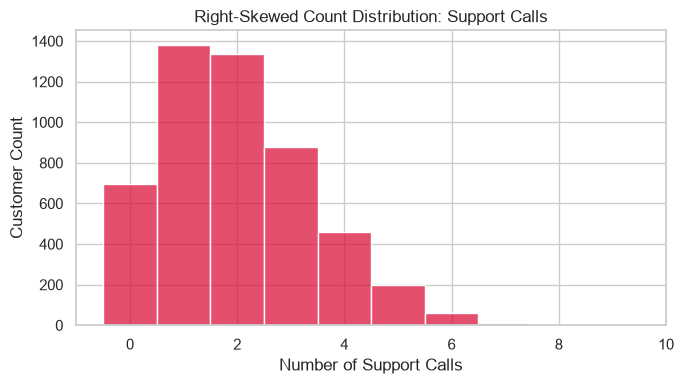

In [20]:
plt.figure(figsize=(7, 4))
sns.histplot(df['SupportCalls'], discrete=True, color='crimson')

plt.title('Right-Skewed Count Distribution: Support Calls')
plt.xlabel('Number of Support Calls')
plt.ylabel('Customer Count')
plt.tight_layout()
plt.show()